# 05 - Beyond Accuracy: Precision vs Recall

With imbalanced data (22.6% positive), accuracy can be misleading.
Let's understand precision, recall, and F1 score.

In [1]:
import sys
from pathlib import Path

# workshop_3/ holds _fetch.py and _sources.py; src/ holds the project's own helpers.
# When opened in Jupyter Lab with Workshop/ as root, Path.cwd() is Workshop/
# so we need to add workshop_3/ and src/ to the path.
for p in (Path.cwd() / "workshop_3", Path.cwd() / "src"):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import _fetch
import _sources as S
from ocean_data_workshop.dsn import dsn
import psycopg

# ML imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Setup
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("ML Workshop Environment Ready")
print("=" * 60)
print("Data sources:")
print("  - NDBC 46092 (wind)")
print("  - GLORYS12V1 (ocean)")
print("  - SanctSound MB01 (acoustic)")
print("=" * 60)

ML Workshop Environment Ready
Data sources:
  - NDBC 46092 (wind)
  - GLORYS12V1 (ocean)
  - SanctSound MB01 (acoustic)


## The accuracy paradox

With 22.6% positive rate, a "never predict positive" model gets 77.4% accuracy!

Let's see this in action.

In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Simulate predictions
y_true = np.array([1] * 100 + [0] * 350)  # 100 positive, 350 negative

# Strategy 1: Always predict negative
y_pred_never = np.zeros(len(y_true), dtype=int)

# Strategy 2: Always predict positive  
y_pred_always = np.ones(len(y_true), dtype=int)

# Strategy 3: Random with 22.6% positive rate
np.random.seed(42)
y_pred_random = (np.random.random(len(y_true)) < 0.226).astype(int)

def evaluate(name, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = (tp + tn) / len(y_true)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    print(f"  Confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

evaluate("Always negative", y_true, y_pred_never)
evaluate("Always positive", y_true, y_pred_always)
evaluate("Random (22.6%)", y_true, y_pred_random)

print("\n" + "=" * 60)
print("Key insight:")
print("  - Accuracy can be high even with a terrible model")
print("  - Precision = how many predicted positives are real")
print("  - Recall = how many real positives did we find")
print("  - F1 = harmonic mean of precision and recall")
print("=" * 60)


Always negative:
  Accuracy:  0.778
  Precision: 0.000
  Recall:    0.000
  F1 Score:  0.000
  Confusion matrix: TN=350, FP=0, FN=100, TP=0

Always positive:
  Accuracy:  0.222
  Precision: 0.222
  Recall:    1.000
  F1 Score:  0.364
  Confusion matrix: TN=0, FP=350, FN=0, TP=100

Random (22.6%):
  Accuracy:  0.669
  Precision: 0.271
  Recall:    0.290
  F1 Score:  0.280
  Confusion matrix: TN=272, FP=78, FN=71, TP=29

Key insight:
  - Accuracy can be high even with a terrible model
  - Precision = how many predicted positives are real
  - Recall = how many real positives did we find
  - F1 = harmonic mean of precision and recall


## Precision-Recall trade-off

Changing the threshold changes precision and recall.

Optimal threshold: 0.274
  Precision: 0.548
  Recall:    0.582
  F1 Score:  0.564


/var/folders/6_/6bnkvg2j2qd8720cj2rr98080000gn/T/ipykernel_37132/105713379.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  acoustic_df = pd.read_sql_query(query, conn)
/var/folders/6_/6bnkvg2j2qd8720cj2rr98080000gn/T/ipykernel_37132/105713379.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dolphin_df = pd.read_sql_query(query2, conn)


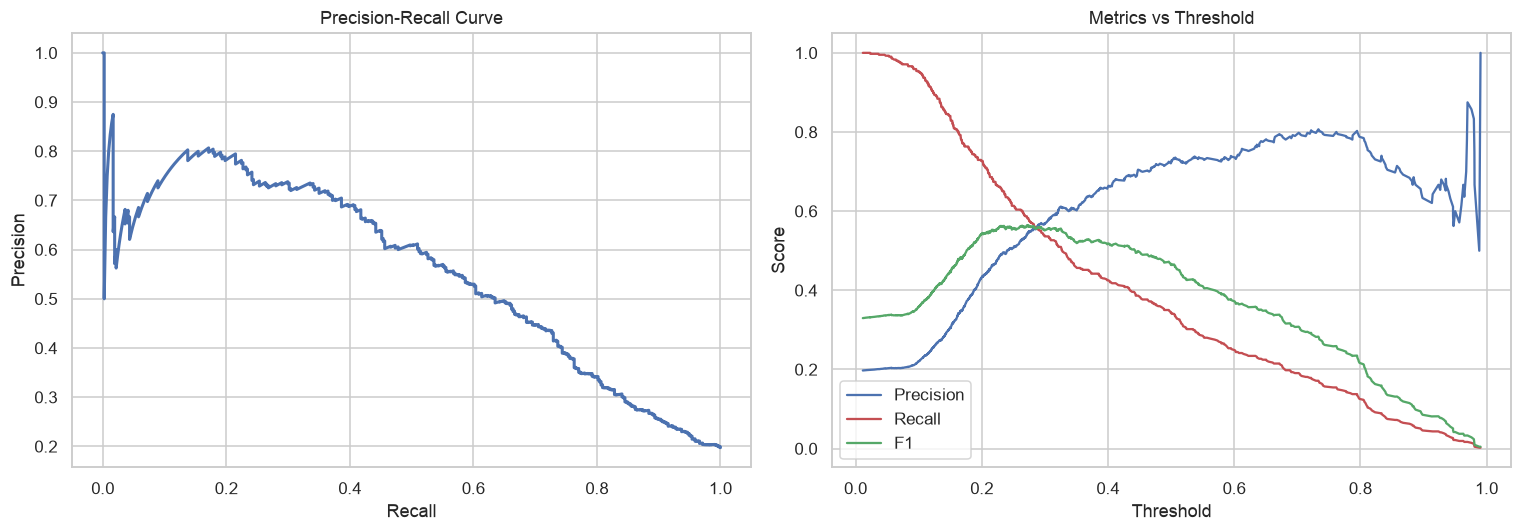

In [3]:
from sklearn.metrics import precision_recall_curve

# Load real data
conn = psycopg.connect(dsn())
query = "SELECT observed_at, site_id,"
query += " band_25hz, band_50hz, band_160hz,"
query += " band_500hz, band_2500hz, band_20000hz"
query += " FROM acoustic_tol_hourly WHERE site_id = 'mb01' ORDER BY observed_at"

acoustic_df = pd.read_sql_query(query, conn)

query2 = "SELECT observed_at, presence FROM detection_hourly"
query2 += " WHERE taxon = 'dolphin' AND is_event_list = FALSE ORDER BY observed_at"

dolphin_df = pd.read_sql_query(query2, conn)

conn.close()

merged = acoustic_df.merge(dolphin_df, on='observed_at')
X = merged[[c for c in merged.columns if c.startswith('band_')]].values
y = merged['presence'].values

# Split
split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Get probabilities
y_proba = model.predict_proba(X_test)[:, 1]

# Precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
ax[0].plot(recalls, precisions, 'b-', linewidth=2)
ax[0].set_xlabel('Recall')
ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall Curve')
ax[0].grid(True)

# Threshold vs metrics
f1_scores = 2 * precisions * recalls / (precisions + recalls)
ax[1].plot(thresholds, precisions[:-1], 'b-', label='Precision')
ax[1].plot(thresholds, recalls[:-1], 'r-', label='Recall')
ax[1].plot(thresholds, f1_scores[:-1], 'g-', label='F1')
ax[1].set_xlabel('Threshold')
ax[1].set_ylabel('Score')
ax[1].set_title('Metrics vs Threshold')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()

# Find optimal threshold
optimal_idx = np.argmax(f1_scores[:-1])
print(f"Optimal threshold: {thresholds[optimal_idx]:.3f}")
print(f"  Precision: {precisions[optimal_idx]:.3f}")
print(f"  Recall:    {recalls[optimal_idx]:.3f}")
print(f"  F1 Score:  {f1_scores[optimal_idx]:.3f}")

## The lesson

- High precision: Few false positives (good for trusted systems)
- High recall: Few false negatives (good for detection systems)
- F1: Balance between the two

Choose based on your application's needs!